---
title: What's the Fastest Way to Download an Earth Engine Image?
category: Blog
tags: python, wxee, benchmarking, earth-engine
date: "2023-04-10"
summary: How do urllib, requests, and fsspec compare for download time when grabbing an image from Earth Engine? Let's run some benchmarking to figure out.
---

There are two ways to download image data from Earth Engine--exporting to Drive or downloading from URL. Each has pros and cons, but for quickly pulling data into Python, URL downloading is the only option (just watch out for the pesky 32 Mb [file size limit](https://developers.google.com/earth-engine/apidocs/ee-image-getdownloadurl)). I built a [Python package called wxee](https://github.com/aazuspan/wxee) a while back that uses the URL download system to turn Earth Engine image collections into [xarray](https://xarray.dev/) datasets, and as part of some much-needed improvements to that package, I decided to take a closer look at the download system to see if there's any room for performance improvements. That means it's time for some benchmarking!

## The Contenders

There are a lot of ways to download a URL in Python. We're going to focus on three packages: [urllib](https://docs.python.org/3/library/urllib.html), [requests](https://requests.readthedocs.io/en/latest/), and [fsspec](https://github.com/fsspec/filesystem_spec). `urllib` is pretty bare-bones, but it gets points for being the only option in the standard library. `requests` is probably the most popular package for making network requests in Python, and it's what the current `wxee` implementation is built on on. `fsspec` is an interesting project that provides a consistent filesystem interace to a variety of storage systems, from local files to HTTP servers to S3 buckets. `fsspec` gives us two ways to access files ([open](https://filesystem-spec.readthedocs.io/en/latest/api.html#fsspec.open) and [cat](https://filesystem-spec.readthedocs.io/en/latest/async.html?highlight=asyncfilesystem#fsspec.asyn.AsyncFileSystem)), so we'll have two tests for that.

In each case, we'll test their performance at turning an image URL from Earth Engine into data that we can open with [rasterio](https://rasterio.readthedocs.io/en/stable/).

In [1]:
import requests
import urllib
import fsspec
import io
import rasterio


def download_urllib(url: str):
    """Download a file using urllib."""
    response = urllib.request.urlopen(url)
    file_obj = io.BytesIO(response.read())
    assert rasterio.open(file_obj)

def download_requests(url: str):
    """Download a file using requests."""
    response = requests.get(url)
    file_obj = io.BytesIO(response.content)
    assert rasterio.open(file_obj)

def download_fsspec_open(url: str):
    """Download a file using fsspec.open."""
    fs = fsspec.filesystem("https")
    file_obj = fs.open(url)
    assert rasterio.open(file_obj)

def download_fsspec_cat(url: str):
    """Download a file using fsspec.cat."""
    fs = fsspec.filesystem("https")
    file_obj = io.BytesIO(fs.cat(url))
    assert rasterio.open(file_obj)

## The Benchmark

Benchmarking Earth Engine code is difficult for a few reasons. 1) You're combining local code execution time with network latency and server-side execution time. The only way we can accomodate for that is by running repeated tests and averaging results. It's not perfect, but it should give us a decent idea of real-world performance. 2) We don't know what the Earth Engine servers are actually doing that might affect performance with repeated runs. It's clear that some [caching takes place](https://developers.google.com/earth-engine/guides/usage), but when and how much isn't clear. To deal with that, we'll generate a different random image each run to (hopefully) prevent any caching that would affect our results.

### Generating Random Images

The function below will generate a 100 x 100 Earth Engine image with random integer pixels and return a URL to download it. We'll use the current time as a seed to make sure we get a different image each run and avoid any possibility of caching.

In [2]:
import ee
import time

ee.Initialize()


def get_random_url() -> str:
    """Return a download URL for a randomized image."""
    img = ee.Image.random(seed=int(time.time() * 1_000)).multiply(100).uint8()
    aoi = ee.Geometry.Point([0, 10]).buffer(49)

    return img.getDownloadURL(
        dict(
            region=aoi,
            crs="EPSG:3857",
            scale=1,
            format="GEO_TIFF"
        )
    )

### Timing the Download

Nothing fancy here. We'll take a download function and run it `n` times to get some benchmark stats. The only trick is that we'll grab our download URL outside the timing loop to cut down on variables in our test.

In [3]:
import time
import numpy as np


def time_downloads(download_function, n: int=10) -> np.array:
    """Time a download function n times."""
    times = np.zeros(n)
    for i in range(n):
        url = get_random_url()
        start = time.time()
        download_function(url)
        times[i] = time.time() - start
    return times

## The Results

Let's fire it up and see how it goes, running each test 30 times.

In [4]:
import pandas as pd
import plotly.express as px
from plotly.io import renderers
renderers.default = "svg"


results = []
for fnc in [download_urllib, download_requests, download_fsspec_open, download_fsspec_cat]:
    times = time_downloads(fnc, n=10)
    results.append(pd.DataFrame(dict(
        function=fnc.__name__.split("download_")[1],
        time=times
    )))

results = pd.concat(results)

How do they compare?

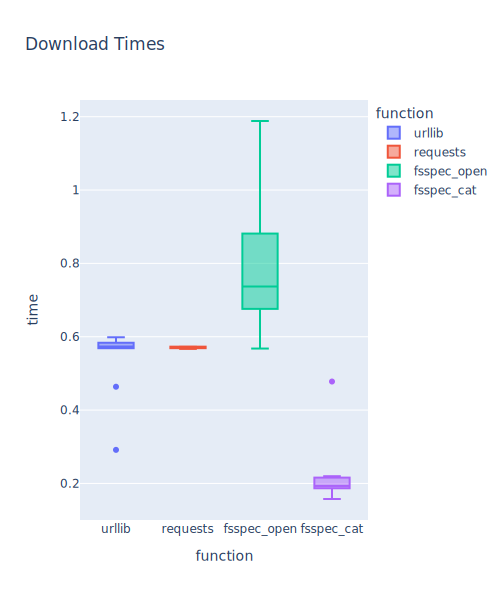

In [17]:
px.box(results, x="function", y="time", color="function", title="Download Times", width=500, height=600)

`requests` and `urllib` did about the same, which isn't surprising given that `requests` is built on `urllib3`. Interestingly, `fsspec` gave us the slowest *and* fastest times depending on the download method. Despite the poor performance of the `open` method in `fsspec`, the `cat` method was *blazingly* fast compared to our other competitors, and looks like the clear winner.

## It's Actually Working, Right?

`fsspec` is the fastest option by far, but maybe we should make sure it's actually doing what we think it is. Instead of some random data, let's grab a real image from the GOES-17 geostationary satellite so we can make sure everything looks right.

In [6]:
import numpy as np
import matplotlib.pyplot as plt


img = (ee.ImageCollection("NOAA/GOES/16/MCMIPC")
       .select(["CMI_C02", "CMI_C03", "CMI_C01"])
       .filterDate("2021-06-20T22", "2022").first()
)

url = img.getDownloadURL(dict(
    scale=8_000,
    crs="EPSG:5070",
    format="GEO_TIFF"
))

Let's download the URL we just grabbed using the same basic function as before.

In [7]:
byte_data = io.BytesIO(fsspec.filesystem("https").cat(url))
with rasterio.open(byte_data) as src:
    data = src.read()

And, after making a few adjustments to make sure it displays correctly, let's see how it looks.

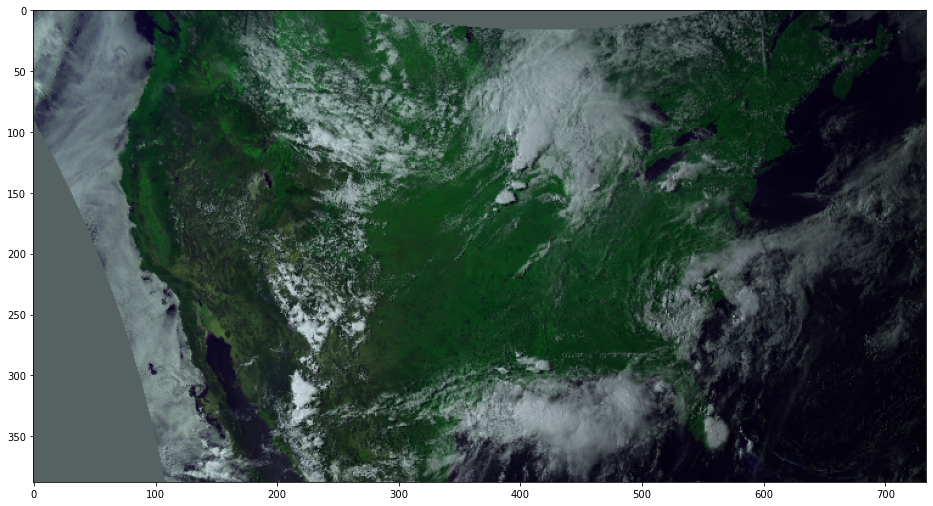

In [8]:
rgb = np.moveaxis(data, 0, 2)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(16, 16))
plt.imshow(rgb)

Looking good! The `fsspec.filesystem.cat` method is working as expected, and it seems to offer a big performance boost over the current `requests` implementation we're using in `wxee`. 

Why does it perform so much better? No idea! `fsspec` offers some fancy features like async execution and local caching, but I don't think our example is taking advantage of that. I'd be fascinated to hear from someone with more experience with the package or network requests in general, but until them I'm happy to accept a 70% decrease in download times!